In [18]:
import numpy as np
import matplotlib.pyplot as plt
import os
from pathlib import Path
import pandas as pd

import torch
import torch.nn as nn

from tqdm import tqdm

from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler

Set seed and turn of non-deterministic behavior for reproducibility

In [2]:
SEED = 2026

def set_seed(seed: int = 2026) -> None:
    """Set seed and disable non-deterministic behavior for reproducibility"""
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True

Set device

In [3]:
def set_device(device: str = 'cpu') -> str:
    """Set device to CUDA if available. Set to cpu if not."""
    if torch.cuda.is_available():
        device = 'cuda'
    else:
        device = 'cpu'
    return device

device = set_device()

Change working directory

In [4]:
notebook_path = %pwd

os.chdir(Path(notebook_path).parent.parent.parent)
os.getcwd()

'/home/atleeri/repositories/forecast-electricity-markets'

Load Processed Data

In [34]:
processed_data_dir = Path('data/processed/')
filepaths = list(processed_data_dir.glob('**/*60*.parquet'))
filepaths

for filepath in filepaths:
    if 'train' in filepath.parts:
        df_train = pd.read_parquet(filepath)
    elif 'validation' in filepath.parts:
        df_val = pd.read_parquet(filepath)
    elif 'test' in filepath.parts:
        df_test = pd.read_parquet(filepath)

Scale data

In [108]:
scaler = MinMaxScaler()

train_norm = scaler.fit_transform(df_train[['DE_wind_generation', 'DE_price_ahead']].values)
val_norm = scaler.fit_transform(df_train[['DE_wind_generation', 'DE_price_ahead']].values)
test_norm = scaler.fit_transform(df_train[['DE_wind_generation', 'DE_price_ahead']].values)

features_train = train_norm
targets_train = train_norm[:,-1:]

features_val = val_norm
targets_val = val_norm[:,-1:]

features_test = test_norm
targets_test = test_norm[:,-1:]

## Forecast price ahead using both historical price data and wind generation

Create sequences

In [112]:
def create_sequences(features, targets, input_len: int = 48, horizon: int = 24):
    """Create sequences for seq2seq forecasting
    
    Args:
        features: data to use in forecast
        targets: data to forecast
        input_len: past timesteps to use in forecast (encoder window length)
        horizon: future timesteps to forecast (decoder window length)

    Returns:
        X: (n_samples, input_len, n_features) inputs to encoder
        y: (n_samples, horizon, n_targets) targets (labels) for decoder
    """

    n_samples = len(features)

    X = np.empty((n_samples - input_len - horizon, input_len, features.shape[-1]))
    y = np.empty((n_samples - input_len - horizon, horizon, targets.shape[-1]))

    for i_sample in range(n_samples - input_len - horizon):
        for i_feature in range(features.shape[-1]):
            X[i_sample,:,i_feature] = features[i_sample:(i_sample + input_len), i_feature]

        for i_feature in range(targets.shape[-1]):
            y[i_sample,:,i_feature] = targets[(i_sample + input_len):(i_sample + input_len + horizon), i_feature]

    return np.array(X), np.array(y)

In [113]:
input_len = 48
horizon = 24

In [114]:
if targets_train.ndim == 1:
    targets_train = np.expand_dims(targets_train, axis=-1)
    targets_val = np.expand_dims(targets_val, axis=-1)
    targets_test = np.expand_dims(targets_test, axis=-1)

X_train, y_train = create_sequences(features_train, targets_train, input_len, horizon)
X_val, y_val = create_sequences(features_val, targets_val, input_len, horizon)
X_test, y_test = create_sequences(features_test, targets_test, input_len, horizon)

In [115]:
features_train = df_train[['DE_wind_generation', 'DE_price_ahead']].values
features_train_norm = MinMaxScaler().fit_transform(features_train)

Create Seq2Seq Model

In [119]:
class Seq2SeqGRU(nn.Module):
    def __init__(self, enc_input_size: int = 2, dec_input_size: int = 1, hidden_size: int = 10, num_layers: int = 1,):
        super().__init__()
        self.encoder = nn.GRU(input_size=enc_input_size, hidden_size=hidden_size, batch_first=True, device=device)
        self.decoder = nn.GRU(input_size=dec_input_size, hidden_size=hidden_size, batch_first=True, device=device)
        self.fc = nn.Linear(hidden_size, dec_input_size)

    def forward(self, X, horizon: int = 24):

        # encode input
        enc_output, hidden = self.encoder(X)
        #print(f'enc_output.shape: {enc_output.shape}')

        #print(f'encoder hidden.shape: {hidden.shape}')

        # seed for decoder: the last observed price
        dec_input = X[:, -1:, 1:2] # dims: (batch, 1, 1)

        #print(f'X.shape: {X.shape}, dec_input.shape: {dec_input.shape}')

        predictions = []
        for time_step in range(horizon):
            # decode
            dec_output, hidden = self.decoder(dec_input, hidden)
            #print(f'dec_output: {dec_output.shape}, decoder hidden.shape: {hidden.shape}')

            # make prediction from output of decoder
            prediction = self.fc(dec_output)
            #print(f'prediction.shape: {prediction.shape}')
            predictions.append(prediction)

            # TODO: add random teacher forcing. For now, just use current prediction as input to next prediction
            dec_input = prediction

        # concatinate over dim 1 so that horizon is on second dimension and batches on first
        return torch.cat(predictions, dim=1)

In [120]:
model = Seq2SeqGRU(enc_input_size=2, dec_input_size = 1)

In [122]:
X_train = torch.tensor(X_train, dtype = torch.float32)
y_train = torch.tensor(y_train, dtype = torch.float32)

Train

In [129]:
learning_rate = 0.1
nepochs = 20

optimizer = torch.optim.Adam(lr = learning_rate, params=model.parameters())

criterion = nn.MSELoss()

losses = []
for epoch in tqdm(range(nepochs)):
    optimizer.zero_grad()

    predictions = model(X, horizon=horizon)

    loss = criterion(predictions, y)

    loss.backward()

    optimizer.step()

    losses.append(loss.item())

100%|██████████| 20/20 [00:18<00:00,  1.06it/s]


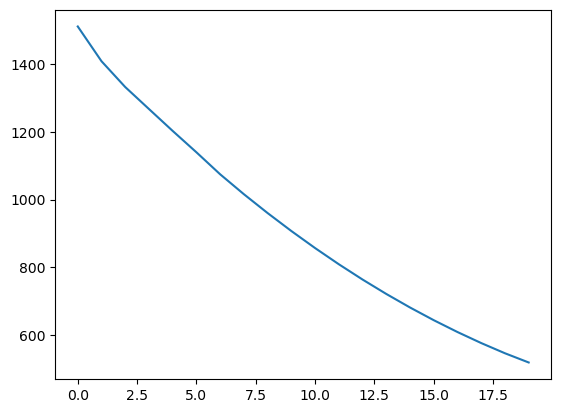

In [131]:
plt.plot(losses)

In [132]:
X_test = torch.tensor(X_test, dtype = torch.float32)
y_test = torch.tensor(y_test, dtype = torch.float32)
with torch.no_grad():
    y_pred = model(X_test)



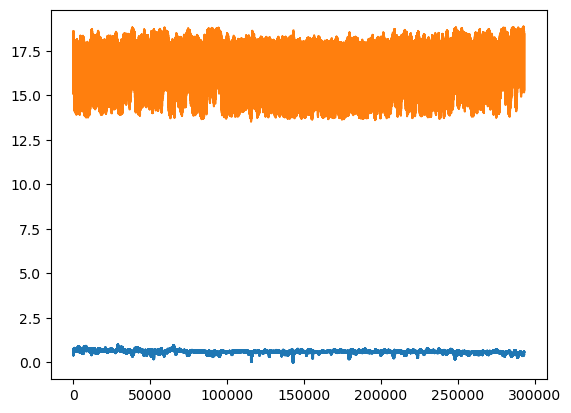

In [138]:
plt.plot(y_test.flatten())
plt.plot(y_pred.flatten())